# Sampler Quickstart — Binary Lens Static

A minimal example of Bayesian sampling with `lcbinint`:

1. Generate a synthetic binary-lens light curve with Gaussian noise
2. Build a `bayes.Model` with priors and flux marginalisation
3. Find the MAP (Levenberg–Marquardt, starting from the input parameters)
4. Initialise walkers with the Hessian at the MAP (`hessian_init=True`)
5. Run the ensemble sampler and inspect the posterior

> **Note on parameter choice**  
> Binary lens posteriors can be multimodal (close/wide degeneracy, α degeneracy).  
> The parameters here (`s=1.3, q=0.1`) give a well-behaved unimodal posterior.  
> For degenerate problems a parallel-tempering sampler or a grid-based search is preferred.

In [1]:
import sys
from pathlib import Path

for build_dir in ("build", "build_new"):
    p = next(
        (r / build_dir for r in (Path.cwd(), *Path.cwd().parents) if (r / build_dir).is_dir()),
        None,
    )
    if p is not None:
        sys.path.insert(0, str(p))
        break

import numpy as np
import matplotlib.pyplot as plt
import lcbinint as lci

print("lcbinint:", lci.__file__)

lcbinint: /rogue1_8/nunota/lcbinint/build/lcbinint/__init__.py


## 1. Synthetic Data

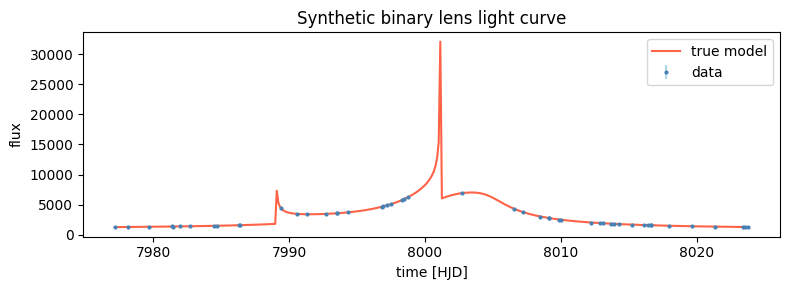

True parameters: {'t0': 8000.0, 'tE': 20.0, 'u0': 0.1, 's': 1.3, 'q': 0.1, 'alpha': 0.5}
Peak magnification: 6.88


In [2]:
rng = np.random.default_rng(42)

# Ground-truth parameters
TRUE = dict(t0=8000.0, tE=20.0, u0=0.10, s=1.3, q=0.10, alpha=0.5)
Fs_true, Fb_true, sigma = 1000.0, 50.0, 30.0

times    = np.sort(rng.uniform(TRUE["t0"] - 25, TRUE["t0"] + 25, 50))
lc_ref   = lci.lc.LightCurve()
mag_true = lc_ref(times, **TRUE)
flux_obs = Fs_true * mag_true + Fb_true + rng.normal(0, sigma, len(times))
flux_err = np.full(len(times), sigma)

t_dense = np.linspace(times[0], times[-1], 400)
fig, ax = plt.subplots(figsize=(8, 3))
ax.errorbar(times, flux_obs, flux_err, fmt=".", ms=4,
            color="steelblue", ecolor="lightblue", label="data", zorder=3)
ax.plot(t_dense, Fs_true * lc_ref(t_dense, **TRUE) + Fb_true,
        color="tomato", lw=1.5, label="true model")
ax.set(xlabel="time [HJD]", ylabel="flux", title="Synthetic binary lens light curve")
ax.legend()
plt.tight_layout()
plt.show()
print("True parameters:", TRUE)
print(f"Peak magnification: {mag_true.max():.2f}")

## 2. Model Setup

`model.flux()` analytically marginalises the linear flux parameters $F_s$ and $F_b$,  
so only the 6 lens parameters are sampled.

`LogUniform` for `q` samples in log space — important when `q` can span orders of magnitude.

In [3]:
data     = lci.obs.LightCurveData(times, flux_obs, flux_err, name="synthetic")
lc_model = lci.lc.LightCurve()
model    = lci.bayes.Model(light_curve=lc_model, data=data)

model.param("t0",    lci.bayes.Uniform(7990, 8010))
model.param("tE",    lci.bayes.Uniform(5, 60))
model.param("u0",    lci.bayes.Uniform(0.0, 1.0))
model.param("s",     lci.bayes.Uniform(0.5, 2.0))
model.param("q",     lci.bayes.LogUniform(1e-3, 0.5))  # sampled in log space
model.param("alpha", lci.bayes.Uniform(0, np.pi))

model.flux()        # marginalise Fs, Fb analytically
model.likelihood()  # Gaussian likelihood

print("Params to sample:", model.param_names)

# Sanity check: log_prob at truth (q is passed in log space)
theta_true_s = [TRUE["t0"], TRUE["tE"], TRUE["u0"], TRUE["s"],
                np.log(TRUE["q"]), TRUE["alpha"]]
print(f"log_prob at truth: {model.log_prob(theta_true_s):.2f}")
print(f"chi2     at truth: {model.chi2(theta_true_s):.2f}  (n_data={model.n_data})")

Params to sample: ['t0', 'tE', 'u0', 's', 'q', 'alpha']
log_prob at truth: -24.69
chi2     at truth: 28.62  (n_data=50)


## 3. MAP Estimate (Levenberg–Marquardt)

Binary lens posteriors are sharply peaked.  
We start LM from the known input parameters to quickly find the MAP,  
then use the Hessian at the MAP to initialise the walkers (`hessian_init=True`).

In a real analysis you would replace the starting point with the output of a grid search  
or a global optimiser such as `lci.optimize.DifferentialEvolution`.

In [4]:
lm      = lci.optimize.LevenbergMarquardt()
res_map = lm.minimize(model, start=theta_true_s)

print(f"LM success={res_map.success}  chi2={res_map.chi2:.4f}  log_prob={res_map.log_prob:.4f}")
print("MAP parameters:")
for k, v in res_map.parameters.items():
    print(f"  {k:6s}: {v:.5f}   (truth: {TRUE[k]:.5f})")

LM success=True  chi2=23.6557  log_prob=-22.2080
MAP parameters:
  alpha : 0.52182   (truth: 0.50000)
  s     : 1.28816   (truth: 1.30000)
  u0    : 0.09631   (truth: 0.10000)
  q     : 0.10005   (truth: 0.10000)
  tE    : 20.34607   (truth: 20.00000)
  t0    : 7999.90797   (truth: 8000.00000)


## 4. MCMC Sampling

`hessian_init=True` computes the Hessian of the negative log-posterior at the MAP  
and disperses walkers according to the resulting Laplace covariance.  
32 walkers, 500 burn-in + 4000 production steps (~6 s).

In [5]:
opts  = lci.SamplerOptions(nwalkers=32, log_every=500, auto_stop=False)
chain = lci.run_sampler(model, nsteps=4000, burnin=500,
                        start=res_map, hessian_init=True, options=opts)

print(chain)
print(f"Acceptance fraction: {chain.acceptance_fraction:.3f}  (ideal ≈ 0.2–0.5)")

taus = chain.tau()
tau_max = max(taus)
print(f"Autocorrelation times: {dict(zip(chain.param_names, [f'{v:.0f}' for v in taus]))}")
print(f"nsteps / tau_max = {4000 / tau_max:.1f}  (need > 50 for full convergence)")

lcbinint sampler | 32 walkers | 6 params | burnin=500 | nsteps=4000


  [burnin 500/500]  accept=0.499


  Burnin done. Starting production run.


  [step  500/4000]  accept=0.500  log_prob=-24.64  elapsed=1.2s


  [step 1000/4000]  accept=0.499  log_prob=-24.99  elapsed=1.8s


...

  [step 3000/4000]  accept=0.501  log_prob=-24.39  elapsed=4.2s


  [step 3500/4000]  accept=0.500  log_prob=-24.65  elapsed=4.8s


  [step 4000/4000]  accept=0.500  log_prob=-25.65  elapsed=5.4s


  Done. 4000 production steps | accept=0.500 | elapsed=5.4s


<sample.Chain nsteps=4000 nwalkers=32 ndim=6 acceptance=0.499>
Acceptance fraction: 0.500  (ideal ≈ 0.2–0.5)
Autocorrelation times: {'t0': '80', 'tE': '91', 'u0': '95', 's': '93', 'q': '73', 'alpha': '95'}
nsteps / tau_max = 42.2  (need > 50 for full convergence)


## 5. Chain Traces

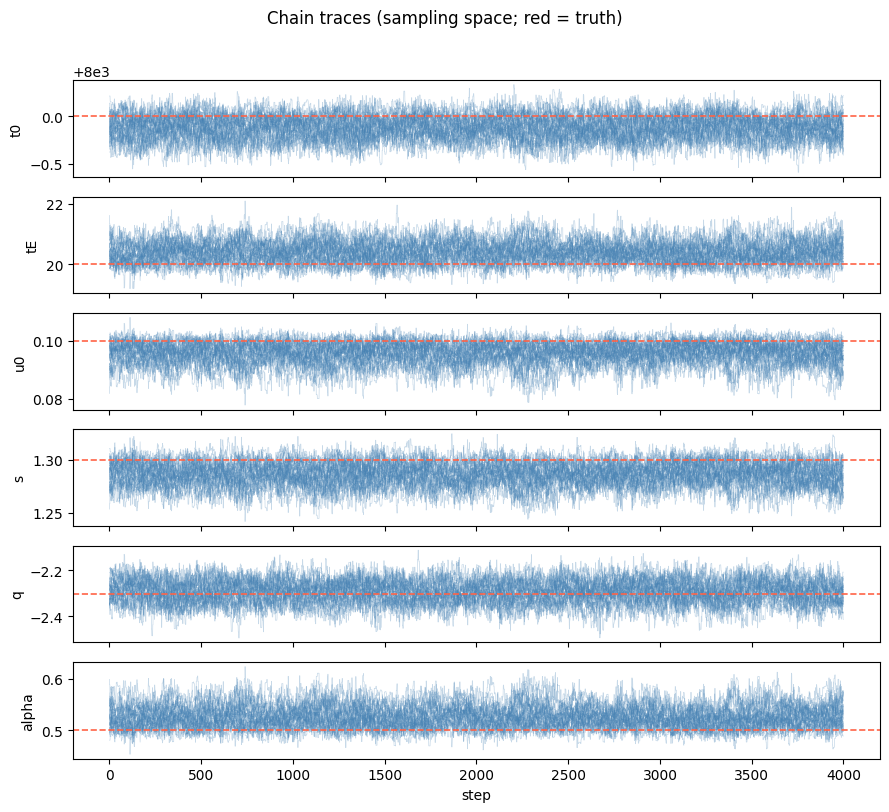

In [6]:
labels     = model.param_names
transforms = chain.transforms          # ["" or "log"] per param
chain_3d   = chain.get_chain()         # (nsteps, nwalkers, ndim) — sampling space
true_vals  = [TRUE["t0"], TRUE["tE"], TRUE["u0"], TRUE["s"], TRUE["q"], TRUE["alpha"]]

fig, axes = plt.subplots(len(labels), 1, figsize=(9, 8), sharex=True)
for i, (ax, lbl, tv) in enumerate(zip(axes, labels, true_vals)):
    ax.plot(chain_3d[:, :, i], alpha=0.3, lw=0.5, color="steelblue")
    ax.set_ylabel(lbl)
    tv_s = np.log(tv) if (transforms and transforms[i] == "log") else tv
    ax.axhline(tv_s, color="tomato", lw=1.2, ls="--")
axes[-1].set_xlabel("step")
fig.suptitle("Chain traces (sampling space; red = truth)", y=1.01)
plt.tight_layout()
plt.show()

## 6. Posterior Marginals

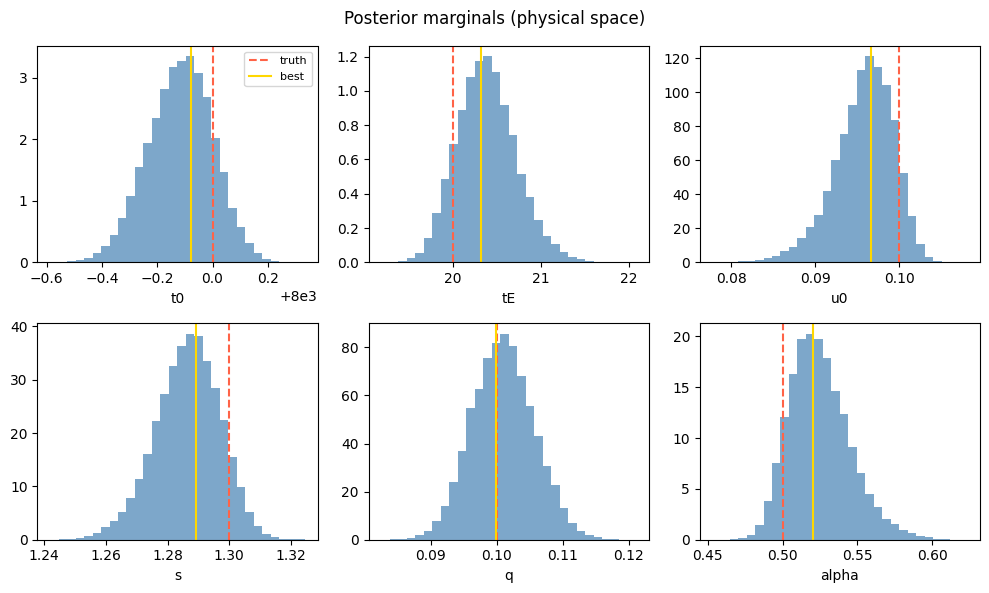

param      truth      best    median        lo        hi
t0      8000.0000  7999.9214  7999.8890  7999.7645  8000.0004
tE       20.0000   20.3233   20.3696   20.0481   20.7124
u0        0.1000    0.0966    0.0962    0.0924    0.0992
s         1.3000    1.2893    1.2870    1.2761    1.2969
q         0.1000    0.0998    0.1009    0.0962    0.1056
alpha     0.5000    0.5202    0.5231    0.5053    0.5448


In [7]:
samples_phys = chain.samples   # (nsteps × nwalkers, ndim) — physical space
flat_lp      = chain.flat_log_prob
best_idx     = int(np.argmax(flat_lp))
best_phys    = samples_phys[best_idx]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for i, (ax, lbl, tv) in enumerate(zip(axes.flat, labels, true_vals)):
    ax.hist(samples_phys[:, i], bins=30, color="steelblue", alpha=0.7, density=True)
    ax.axvline(tv,           color="tomato", lw=1.5, ls="--", label="truth")
    ax.axvline(best_phys[i], color="gold",   lw=1.5, ls="-",  label="best")
    ax.set_xlabel(lbl)
    if i == 0:
        ax.legend(fontsize=8)
plt.suptitle("Posterior marginals (physical space)")
plt.tight_layout()
plt.show()

print(f"{'param':6s}  {'truth':>8s}  {'best':>8s}  {'median':>8s}  {'lo':>8s}  {'hi':>8s}")
for i, (lbl, tv) in enumerate(zip(labels, true_vals)):
    s = chain.summary()[lbl]
    print(f"{lbl:6s}  {tv:8.4f}  {best_phys[i]:8.4f}  {s['median']:8.4f}  {s['lo']:8.4f}  {s['hi']:8.4f}")

## 7. Best-Fit Overlay

We use the sample with the highest log-posterior (best) rather than the median  
to show the light curve fit — the best sample is a valid draw from the posterior  
that is closest to the MAP.

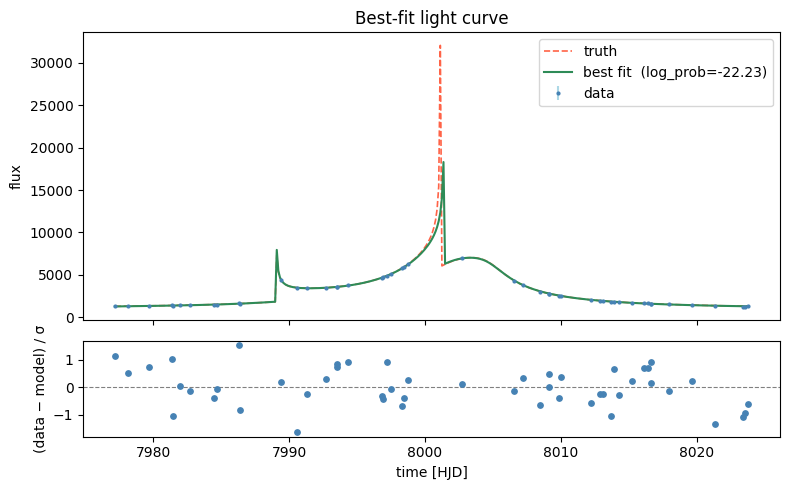

Recovered Fs = 989.6  (truth 1000.0)
Recovered Fb = 44.2  (truth 50.0)


In [8]:
# best sample in sampling space (needed for model.fluxes)
best_theta_raw = chain.flat_samples[best_idx].tolist()
fluxes_best    = model.fluxes(best_theta_raw)
Fs_best = fluxes_best["synthetic"]["Fs"]
Fb_best = fluxes_best["synthetic"]["Fb"]

mag_best  = lc_model(t_dense, **dict(zip(labels, best_phys)))
flux_best = Fs_best * mag_best + Fb_best

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
ax1.errorbar(times, flux_obs, flux_err, fmt=".", ms=4,
             color="steelblue", ecolor="lightblue", zorder=3, label="data")
ax1.plot(t_dense, Fs_true * lc_ref(t_dense, **TRUE) + Fb_true,
         color="tomato", lw=1.2, ls="--", label="truth")
ax1.plot(t_dense, flux_best, color="seagreen", lw=1.5,
         label=f"best fit  (log_prob={flat_lp[best_idx]:.2f})")
ax1.set_ylabel("flux")
ax1.set_title("Best-fit light curve")
ax1.legend()

flux_at_data = Fs_best * lc_model(times, **dict(zip(labels, best_phys))) + Fb_best
ax2.scatter(times, (flux_obs - flux_at_data) / flux_err,
            s=15, color="steelblue", zorder=3)
ax2.axhline(0, color="gray", lw=0.8, ls="--")
ax2.set(xlabel="time [HJD]", ylabel="(data − model) / σ")
plt.tight_layout()
plt.show()

print(f"Recovered Fs = {Fs_best:.1f}  (truth {Fs_true:.1f})")
print(f"Recovered Fb = {Fb_best:.1f}  (truth {Fb_true:.1f})")